In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path
import copy
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [3]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Proyecto_PINN_HRF"
)

SYNTHETIC_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "synthetic"
)

NOISY_DATA_DIR = (
    SYNTHETIC_DATA_DIR
    / "noisy"
)

GROUND_TRUTH_HRF_PATH = (
    SYNTHETIC_DATA_DIR
    / "ground_truth_hrf.csv"
)

NOISE_SUMMARY_PATH = (
    PROJECT_ROOT
    / "results"
    / "synthetic"
    / "noise_dataset_summary.csv"
)

MLP_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "synthetic"
    / "mlp"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

CONFIG_DIR = (
    PROJECT_ROOT
    / "configs"
)

for directory in [
    MLP_RESULTS_DIR,
    FIGURES_DIR,
    CONFIG_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Resumen de ruido:", NOISE_SUMMARY_PATH.exists())
print("HRF verdadera:", GROUND_TRUTH_HRF_PATH.exists())

Resumen de ruido: True
HRF verdadera: True


In [4]:
noise_summary = pd.read_csv(
    NOISE_SUMMARY_PATH
)

ground_truth_hrf = pd.read_csv(
    GROUND_TRUTH_HRF_PATH
)

print("Experimentos disponibles:", len(noise_summary))
print("Escenarios:", noise_summary["scenario"].nunique())
print(
    "SNR:",
    sorted(noise_summary["target_snr"].unique()),
)

Experimentos disponibles: 60
Escenarios: 4
SNR: [np.float64(2.0), np.float64(5.0), np.float64(10.0)]


In [5]:
MLP_CONFIG = {
    "maximum_lag_s": 32.0,
    "hidden_layers": [64, 32],
    "activation": "tanh",
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "maximum_epochs": 2500,
    "early_stopping_patience": 200,
    "validation_fraction": 0.20,
    "base_random_seed": 20260717,
}

config_path = (
    CONFIG_DIR
    / "mlp_synthetic_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        MLP_CONFIG,
        file,
        indent=2,
        ensure_ascii=False,
    )

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Dispositivo:", DEVICE)
print("Configuración guardada:", config_path)

Dispositivo: cpu
Configuración guardada: /content/drive/MyDrive/Proyecto_PINN_HRF/configs/mlp_synthetic_config.json


In [6]:
def establecer_semilla(
    seed: int,
) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.use_deterministic_algorithms(
        True,
        warn_only=True,
    )

In [7]:
def construir_matriz_retardos(
    stimulus: np.ndarray,
    n_lags: int,
) -> np.ndarray:
    """
    Construye una matriz causal con el estímulo actual
    y sus valores retardados.

    La columna 0 corresponde a u(t), la columna 1 a
    u(t-TR), etc.
    """
    stimulus = np.asarray(
        stimulus,
        dtype=float,
    ).reshape(-1)

    if n_lags < 1:
        raise ValueError(
            "n_lags debe ser al menos 1."
        )

    n_points = len(stimulus)

    lag_matrix = np.zeros(
        (n_points, n_lags),
        dtype=float,
    )

    for lag in range(n_lags):
        if lag == 0:
            lag_matrix[:, lag] = stimulus
        else:
            lag_matrix[lag:, lag] = (
                stimulus[:-lag]
            )

    return lag_matrix

In [8]:
def ajustar_escalador(
    values: np.ndarray,
    training_mask: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Calcula promedio y desviación estándar usando
    únicamente los puntos de entrenamiento.
    """
    values = np.asarray(
        values,
        dtype=float,
    )

    training_mask = np.asarray(
        training_mask,
        dtype=bool,
    )

    training_values = values[
        training_mask
    ]

    mean = np.mean(
        training_values,
        axis=0,
        keepdims=True,
    )

    standard_deviation = np.std(
        training_values,
        axis=0,
        ddof=0,
        keepdims=True,
    )

    standard_deviation = np.where(
        standard_deviation < 1e-8,
        1.0,
        standard_deviation,
    )

    return mean, standard_deviation

In [9]:
class StimulusHistoryMLP(nn.Module):
    """
    MLP que estima la señal BOLD a partir del historial
    reciente del estímulo.
    """

    def __init__(
        self,
        input_dimension: int,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                input_dimension,
                64,
            ),
            nn.Tanh(),
            nn.Linear(
                64,
                32,
            ),
            nn.Tanh(),
            nn.Linear(
                32,
                1,
            ),
        )

    def forward(
        self,
        inputs: torch.Tensor,
    ) -> torch.Tensor:
        return self.network(inputs)

In [10]:
def correlacion_segura(
    observed: np.ndarray,
    predicted: np.ndarray,
) -> float:
    observed = np.asarray(
        observed,
        dtype=float,
    )

    predicted = np.asarray(
        predicted,
        dtype=float,
    )

    if (
        np.std(observed) < 1e-12
        or np.std(predicted) < 1e-12
    ):
        return np.nan

    return float(
        np.corrcoef(
            observed,
            predicted,
        )[0, 1]
    )

In [11]:
def calcular_metricas(
    observed: np.ndarray,
    predicted: np.ndarray,
) -> dict:
    observed = np.asarray(
        observed,
        dtype=float,
    )

    predicted = np.asarray(
        predicted,
        dtype=float,
    )

    mse = mean_squared_error(
        observed,
        predicted,
    )

    mae = mean_absolute_error(
        observed,
        predicted,
    )

    return {
        "mse_fraction": float(mse),
        "rmse_fraction": float(np.sqrt(mse)),
        "rmse_percent": float(
            100.0 * np.sqrt(mse)
        ),
        "mae_fraction": float(mae),
        "mae_percent": float(
            100.0 * mae
        ),
        "r2": float(
            r2_score(
                observed,
                predicted,
            )
        ),
        "pearson_r": correlacion_segura(
            observed,
            predicted,
        ),
    }

In [12]:
def calcular_metricas_hrf(
    true_hrf: np.ndarray,
    estimated_hrf: np.ndarray,
    time_s: np.ndarray,
) -> dict:
    metrics = calcular_metricas(
        true_hrf,
        estimated_hrf,
    )

    true_peak_index = int(
        np.argmax(true_hrf)
    )

    estimated_peak_index = int(
        np.argmax(estimated_hrf)
    )

    true_peak = float(
        true_hrf[true_peak_index]
    )

    estimated_peak = float(
        estimated_hrf[estimated_peak_index]
    )

    true_peak_time = float(
        time_s[true_peak_index]
    )

    estimated_peak_time = float(
        time_s[estimated_peak_index]
    )

    metrics.update(
        {
            "true_peak_percent": 100.0 * true_peak,
            "estimated_peak_percent": (
                100.0 * estimated_peak
            ),
            "peak_amplitude_error_percent": (
                100.0
                * (
                    estimated_peak
                    - true_peak
                )
            ),
            "true_time_to_peak_s": true_peak_time,
            "estimated_time_to_peak_s": (
                estimated_peak_time
            ),
            "time_to_peak_error_s": (
                estimated_peak_time
                - true_peak_time
            ),
        }
    )

    return metrics

In [13]:
def dividir_entrenamiento_validacion(
    training_mask: np.ndarray,
    validation_fraction: float,
    random_seed: int,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Divide solamente los puntos disponibles para
    entrenamiento. La ventana de prueba no participa.
    """
    available_indices = np.flatnonzero(
        training_mask
    )

    rng = np.random.default_rng(
        random_seed
    )

    shuffled_indices = rng.permutation(
        available_indices
    )

    n_validation = max(
        1,
        int(
            round(
                validation_fraction
                * len(available_indices)
            )
        ),
    )

    validation_indices = (
        shuffled_indices[:n_validation]
    )

    fitting_indices = (
        shuffled_indices[n_validation:]
    )

    return (
        np.sort(fitting_indices),
        np.sort(validation_indices),
    )

In [14]:
def entrenar_mlp(
    input_matrix: np.ndarray,
    target_percent: np.ndarray,
    training_mask: np.ndarray,
    random_seed: int,
) -> dict:
    """
    Entrena una MLP usando solamente los puntos permitidos
    por training_mask.
    """
    establecer_semilla(
        random_seed
    )

    input_matrix = np.asarray(
        input_matrix,
        dtype=float,
    )

    target_percent = np.asarray(
        target_percent,
        dtype=float,
    ).reshape(-1, 1)

    training_mask = np.asarray(
        training_mask,
        dtype=bool,
    )

    fitting_indices, validation_indices = (
        dividir_entrenamiento_validacion(
            training_mask=training_mask,
            validation_fraction=MLP_CONFIG[
                "validation_fraction"
            ],
            random_seed=random_seed,
        )
    )

    x_mean, x_std = ajustar_escalador(
        input_matrix,
        training_mask,
    )

    y_mean, y_std = ajustar_escalador(
        target_percent,
        training_mask,
    )

    x_scaled = (
        input_matrix - x_mean
    ) / x_std

    y_scaled = (
        target_percent - y_mean
    ) / y_std

    x_tensor = torch.tensor(
        x_scaled,
        dtype=torch.float32,
        device=DEVICE,
    )

    y_tensor = torch.tensor(
        y_scaled,
        dtype=torch.float32,
        device=DEVICE,
    )

    fitting_tensor = torch.tensor(
        fitting_indices,
        dtype=torch.long,
        device=DEVICE,
    )

    validation_tensor = torch.tensor(
        validation_indices,
        dtype=torch.long,
        device=DEVICE,
    )

    model = StimulusHistoryMLP(
        input_dimension=input_matrix.shape[1],
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=MLP_CONFIG["learning_rate"],
        weight_decay=MLP_CONFIG["weight_decay"],
    )

    loss_function = nn.MSELoss()

    best_validation_loss = np.inf
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0

    training_history = []

    for epoch in range(
        1,
        MLP_CONFIG["maximum_epochs"] + 1,
    ):
        model.train()

        optimizer.zero_grad()

        fitting_prediction = model(
            x_tensor[fitting_tensor]
        )

        fitting_loss = loss_function(
            fitting_prediction,
            y_tensor[fitting_tensor],
        )

        fitting_loss.backward()
        optimizer.step()

        model.eval()

        with torch.no_grad():
            validation_prediction = model(
                x_tensor[validation_tensor]
            )

            validation_loss = loss_function(
                validation_prediction,
                y_tensor[validation_tensor],
            )

        fitting_loss_value = float(
            fitting_loss.detach().cpu()
        )

        validation_loss_value = float(
            validation_loss.detach().cpu()
        )

        training_history.append(
            {
                "epoch": epoch,
                "training_loss": fitting_loss_value,
                "validation_loss": validation_loss_value,
            }
        )

        if (
            validation_loss_value
            < best_validation_loss - 1e-7
        ):
            best_validation_loss = (
                validation_loss_value
            )

            best_state = copy.deepcopy(
                model.state_dict()
            )

            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= MLP_CONFIG[
                "early_stopping_patience"
            ]
        ):
            break

    if best_state is None:
        raise RuntimeError(
            "No fue posible almacenar un modelo válido."
        )

    model.load_state_dict(
        best_state
    )

    model.eval()

    with torch.no_grad():
        complete_prediction_scaled = (
            model(x_tensor)
            .cpu()
            .numpy()
        )

    complete_prediction_percent = (
        complete_prediction_scaled
        * y_std
        + y_mean
    ).reshape(-1)

    return {
        "model": model,
        "prediction_percent": (
            complete_prediction_percent
        ),
        "x_mean": x_mean,
        "x_std": x_std,
        "y_mean": y_mean,
        "y_std": y_std,
        "best_epoch": int(best_epoch),
        "best_validation_loss": float(
            best_validation_loss
        ),
        "history": pd.DataFrame(
            training_history
        ),
    }

In [15]:
def predecir_con_mlp(
    model: nn.Module,
    input_matrix: np.ndarray,
    x_mean: np.ndarray,
    x_std: np.ndarray,
    y_mean: np.ndarray,
    y_std: np.ndarray,
) -> np.ndarray:
    input_scaled = (
        input_matrix - x_mean
    ) / x_std

    input_tensor = torch.tensor(
        input_scaled,
        dtype=torch.float32,
        device=DEVICE,
    )

    model.eval()

    with torch.no_grad():
        prediction_scaled = (
            model(input_tensor)
            .cpu()
            .numpy()
        )

    prediction_percent = (
        prediction_scaled
        * y_std
        + y_mean
    ).reshape(-1)

    return prediction_percent

In [16]:
def estimar_hrf_mlp(
    training_result: dict,
    tr_s: float,
    n_lags: int,
    evaluation_times_s: np.ndarray,
) -> np.ndarray:
    """
    Estima la respuesta de la MLP a un evento de 1 s.
    """
    event_onset_s = 5.0
    evaluation_duration_s = float(
        np.max(evaluation_times_s)
    )

    simulation_end_s = (
        event_onset_s
        + evaluation_duration_s
        + tr_s
    )

    simulation_times = np.arange(
        0.0,
        simulation_end_s + tr_s / 2.0,
        tr_s,
    )

    stimulus = (
        (
            simulation_times >= event_onset_s
        )
        & (
            simulation_times
            < event_onset_s + 1.0
        )
    ).astype(float)

    lag_matrix = construir_matriz_retardos(
        stimulus,
        n_lags,
    )

    predicted_percent = predecir_con_mlp(
        model=training_result["model"],
        input_matrix=lag_matrix,
        x_mean=training_result["x_mean"],
        x_std=training_result["x_std"],
        y_mean=training_result["y_mean"],
        y_std=training_result["y_std"],
    )

    baseline_mask = (
        simulation_times < event_onset_s
    )

    baseline_percent = float(
        np.mean(
            predicted_percent[baseline_mask]
        )
    )

    relative_times = (
        simulation_times
        - event_onset_s
    )

    post_event_mask = (
        relative_times >= 0.0
    )

    estimated_percent = np.interp(
        evaluation_times_s,
        relative_times[post_event_mask],
        (
            predicted_percent[post_event_mask]
            - baseline_percent
        ),
    )

    return estimated_percent / 100.0

In [17]:
hrf_reference = ground_truth_hrf.loc[
    ground_truth_hrf[
        "time_from_onset_s"
    ] >= 0.0
].copy()

HRF_EVALUATION_TIMES = (
    hrf_reference[
        "time_from_onset_s"
    ].to_numpy(dtype=float)
)

HRF_TRUE = (
    hrf_reference[
        "bold_fraction"
    ].to_numpy(dtype=float)
)

In [18]:
metrics_rows = []
prediction_tables = []
hrf_tables = []
history_tables = []

for experiment_number, (_, experiment) in enumerate(
    noise_summary.iterrows(),
    start=1,
):
    scenario_name = experiment["scenario"]
    snr_name = experiment["snr_name"]
    replicate = int(experiment["replicate"])

    file_name = (
        f"{scenario_name}_"
        f"{snr_name}_"
        f"rep_{replicate:02d}.csv"
    )

    noisy_path = (
        NOISY_DATA_DIR
        / scenario_name
        / snr_name
        / file_name
    )

    table = pd.read_csv(
        noisy_path
    )

    time_s = (
        table["time_s"]
        .to_numpy(dtype=float)
    )

    tr_s = float(
        np.median(
            np.diff(time_s)
        )
    )

    n_lags = int(
        round(
            MLP_CONFIG["maximum_lag_s"]
            / tr_s
        )
    ) + 1

    stimulus = (
        table["stimulus"]
        .to_numpy(dtype=float)
    )

    input_matrix = (
        construir_matriz_retardos(
            stimulus,
            n_lags,
        )
    )

    noisy_signal_fraction = (
        table[
            "bold_noisy_fraction"
        ].to_numpy(dtype=float)
    )

    clean_signal_fraction = (
        table[
            "bold_clean_fraction"
        ].to_numpy(dtype=float)
    )

    training_mask = (
        table["train_mask"]
        .to_numpy(dtype=bool)
    )

    test_mask = (
        table["test_mask"]
        .to_numpy(dtype=bool)
    )

    model_seed = (
        MLP_CONFIG["base_random_seed"]
        + int(experiment["random_seed"])
    )

    training_result = entrenar_mlp(
        input_matrix=input_matrix,
        target_percent=(
            100.0 * noisy_signal_fraction
        ),
        training_mask=training_mask,
        random_seed=model_seed,
    )

    prediction_fraction = (
        training_result[
            "prediction_percent"
        ]
        / 100.0
    )

    test_metrics = calcular_metricas(
        clean_signal_fraction[test_mask],
        prediction_fraction[test_mask],
    )

    training_metrics = calcular_metricas(
        noisy_signal_fraction[training_mask],
        prediction_fraction[training_mask],
    )

    estimated_hrf = estimar_hrf_mlp(
        training_result=training_result,
        tr_s=tr_s,
        n_lags=n_lags,
        evaluation_times_s=(
            HRF_EVALUATION_TIMES
        ),
    )

    hrf_metrics = calcular_metricas_hrf(
        true_hrf=HRF_TRUE,
        estimated_hrf=estimated_hrf,
        time_s=HRF_EVALUATION_TIMES,
    )

    metrics_rows.append(
        {
            "scenario": scenario_name,
            "run": experiment["run"],
            "roi": experiment["roi"],
            "condition": experiment["condition"],
            "snr_name": snr_name,
            "target_snr": float(
                experiment["target_snr"]
            ),
            "replicate": replicate,
            "random_seed": model_seed,
            "n_lags": n_lags,
            "best_epoch": training_result[
                "best_epoch"
            ],
            "best_validation_loss": (
                training_result[
                    "best_validation_loss"
                ]
            ),
            "test_rmse_percent": (
                test_metrics["rmse_percent"]
            ),
            "test_mae_percent": (
                test_metrics["mae_percent"]
            ),
            "test_r2": test_metrics["r2"],
            "test_pearson_r": (
                test_metrics["pearson_r"]
            ),
            "train_rmse_percent": (
                training_metrics["rmse_percent"]
            ),
            "train_r2": (
                training_metrics["r2"]
            ),
            "hrf_rmse_percent": (
                hrf_metrics["rmse_percent"]
            ),
            "hrf_r2": hrf_metrics["r2"],
            "hrf_pearson_r": (
                hrf_metrics["pearson_r"]
            ),
            "hrf_true_peak_percent": (
                hrf_metrics[
                    "true_peak_percent"
                ]
            ),
            "hrf_estimated_peak_percent": (
                hrf_metrics[
                    "estimated_peak_percent"
                ]
            ),
            "hrf_peak_amplitude_error_percent": (
                hrf_metrics[
                    "peak_amplitude_error_percent"
                ]
            ),
            "hrf_true_time_to_peak_s": (
                hrf_metrics[
                    "true_time_to_peak_s"
                ]
            ),
            "hrf_estimated_time_to_peak_s": (
                hrf_metrics[
                    "estimated_time_to_peak_s"
                ]
            ),
            "hrf_time_to_peak_error_s": (
                hrf_metrics[
                    "time_to_peak_error_s"
                ]
            ),
        }
    )

    prediction_tables.append(
        pd.DataFrame(
            {
                "scenario": scenario_name,
                "snr_name": snr_name,
                "target_snr": float(
                    experiment["target_snr"]
                ),
                "replicate": replicate,
                "time_s": time_s,
                "clean_fraction": clean_signal_fraction,
                "noisy_fraction": noisy_signal_fraction,
                "predicted_fraction": prediction_fraction,
                "train_mask": training_mask.astype(int),
                "test_mask": test_mask.astype(int),
            }
        )
    )

    hrf_tables.append(
        pd.DataFrame(
            {
                "scenario": scenario_name,
                "snr_name": snr_name,
                "target_snr": float(
                    experiment["target_snr"]
                ),
                "replicate": replicate,
                "time_from_onset_s": (
                    HRF_EVALUATION_TIMES
                ),
                "true_hrf_fraction": HRF_TRUE,
                "estimated_hrf_fraction": (
                    estimated_hrf
                ),
            }
        )
    )

    history = training_result[
        "history"
    ].copy()

    history.insert(
        0,
        "scenario",
        scenario_name,
    )

    history.insert(
        1,
        "snr_name",
        snr_name,
    )

    history.insert(
        2,
        "replicate",
        replicate,
    )

    history_tables.append(
        history
    )

    if (
        experiment_number == 1
        or experiment_number % 10 == 0
        or experiment_number == len(noise_summary)
    ):
        print(
            f"Procesados: "
            f"{experiment_number}/"
            f"{len(noise_summary)}"
        )

Procesados: 1/60
Procesados: 10/60
Procesados: 20/60
Procesados: 30/60
Procesados: 40/60
Procesados: 50/60
Procesados: 60/60


In [19]:
mlp_metrics = pd.DataFrame(
    metrics_rows
)

mlp_predictions = pd.concat(
    prediction_tables,
    ignore_index=True,
)

mlp_hrf_estimates = pd.concat(
    hrf_tables,
    ignore_index=True,
)

mlp_training_history = pd.concat(
    history_tables,
    ignore_index=True,
)

metrics_path = (
    MLP_RESULTS_DIR
    / "mlp_synthetic_metrics.csv"
)

predictions_path = (
    MLP_RESULTS_DIR
    / "mlp_synthetic_predictions.csv"
)

hrf_path = (
    MLP_RESULTS_DIR
    / "mlp_synthetic_hrf_estimates.csv"
)

history_path = (
    MLP_RESULTS_DIR
    / "mlp_training_history.csv"
)

mlp_metrics.to_csv(
    metrics_path,
    index=False,
)

mlp_predictions.to_csv(
    predictions_path,
    index=False,
)

mlp_hrf_estimates.to_csv(
    hrf_path,
    index=False,
)

mlp_training_history.to_csv(
    history_path,
    index=False,
)

print("Experimentos evaluados:", len(mlp_metrics))
print("Métricas:", metrics_path)
print("Predicciones:", predictions_path)
print("HRF:", hrf_path)

Experimentos evaluados: 60
Métricas: /content/drive/MyDrive/Proyecto_PINN_HRF/results/synthetic/mlp/mlp_synthetic_metrics.csv
Predicciones: /content/drive/MyDrive/Proyecto_PINN_HRF/results/synthetic/mlp/mlp_synthetic_predictions.csv
HRF: /content/drive/MyDrive/Proyecto_PINN_HRF/results/synthetic/mlp/mlp_synthetic_hrf_estimates.csv


In [20]:
mlp_grouped_summary = (
    mlp_metrics
    .groupby(
        [
            "snr_name",
            "target_snr",
        ],
        as_index=False,
    )
    .agg(
        n_experiments=(
            "test_rmse_percent",
            "size",
        ),
        test_rmse_mean=(
            "test_rmse_percent",
            "mean",
        ),
        test_rmse_std=(
            "test_rmse_percent",
            "std",
        ),
        test_mae_mean=(
            "test_mae_percent",
            "mean",
        ),
        test_r2_mean=(
            "test_r2",
            "mean",
        ),
        test_r2_std=(
            "test_r2",
            "std",
        ),
        test_pearson_mean=(
            "test_pearson_r",
            "mean",
        ),
        hrf_rmse_mean=(
            "hrf_rmse_percent",
            "mean",
        ),
        hrf_r2_mean=(
            "hrf_r2",
            "mean",
        ),
        hrf_pearson_mean=(
            "hrf_pearson_r",
            "mean",
        ),
        peak_error_mean=(
            "hrf_peak_amplitude_error_percent",
            "mean",
        ),
        time_peak_error_mean=(
            "hrf_time_to_peak_error_s",
            "mean",
        ),
        best_epoch_mean=(
            "best_epoch",
            "mean",
        ),
    )
    .sort_values(
        "target_snr",
        ascending=False,
    )
)

summary_path = (
    MLP_RESULTS_DIR
    / "mlp_synthetic_grouped_summary.csv"
)

mlp_grouped_summary.to_csv(
    summary_path,
    index=False,
)

display(mlp_grouped_summary)

,snr_name,target_snr,n_experiments,test_rmse_mean,test_rmse_std,test_mae_mean,test_r2_mean,test_r2_std,test_pearson_mean,hrf_rmse_mean,hrf_r2_mean,hrf_pearson_mean,peak_error_mean,time_peak_error_mean,best_epoch_mean
0,snr_10,10.0,20,0.084914,0.032849,0.059683,0.983398,0.014353,0.992531,0.241800,-1.622980,0.845826,0.481243,0.5950,369.30
2,snr_5,5.0,20,0.108782,0.029163,0.083311,0.974516,0.014804,0.989185,0.237348,-1.527684,0.810071,0.436722,0.3025,298.65
1,snr_2,2.0,20,0.210325,0.047071,0.162596,0.906578,0.045303,0.967167,0.242118,-1.662893,0.757992,0.382508,-0.2950,87.20


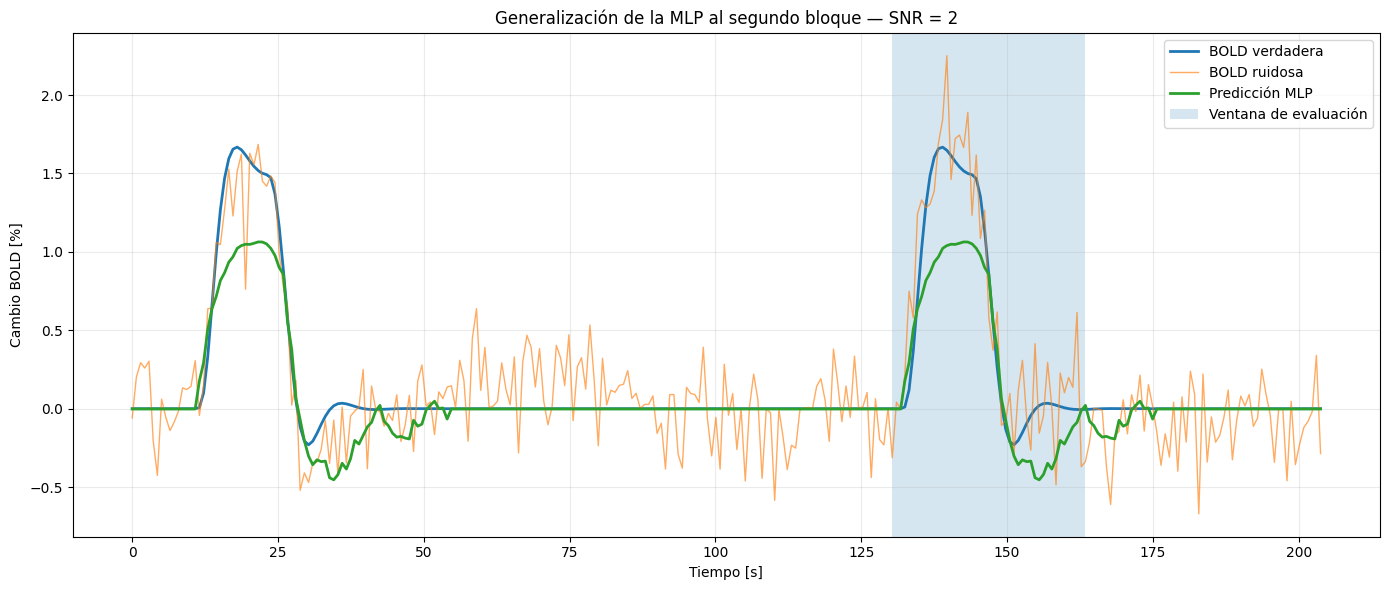

In [21]:
example_prediction = (
    mlp_predictions.loc[
        (
            mlp_predictions["scenario"]
            == "motor_lr_m1_left"
        )
        & (
            mlp_predictions["snr_name"]
            == "snr_2"
        )
        & (
            mlp_predictions["replicate"]
            == 1
        )
    ]
    .copy()
)

test_mask_example = (
    example_prediction["test_mask"]
    .to_numpy(dtype=bool)
)

test_times = example_prediction.loc[
    test_mask_example,
    "time_s",
]

plt.figure(figsize=(14, 6))

plt.plot(
    example_prediction["time_s"],
    100.0
    * example_prediction["clean_fraction"],
    label="BOLD verdadera",
    linewidth=2.0,
)

plt.plot(
    example_prediction["time_s"],
    100.0
    * example_prediction["noisy_fraction"],
    label="BOLD ruidosa",
    linewidth=1.0,
    alpha=0.65,
)

plt.plot(
    example_prediction["time_s"],
    100.0
    * example_prediction["predicted_fraction"],
    label="Predicción MLP",
    linewidth=2.0,
)

plt.axvspan(
    float(test_times.min()),
    float(test_times.max()),
    alpha=0.18,
    label="Ventana de evaluación",
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Cambio BOLD [%]")
plt.title(
    "Generalización de la MLP al segundo bloque — SNR = 2"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

figure_path = (
    FIGURES_DIR
    / "mlp_synthetic_prediction_snr2.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

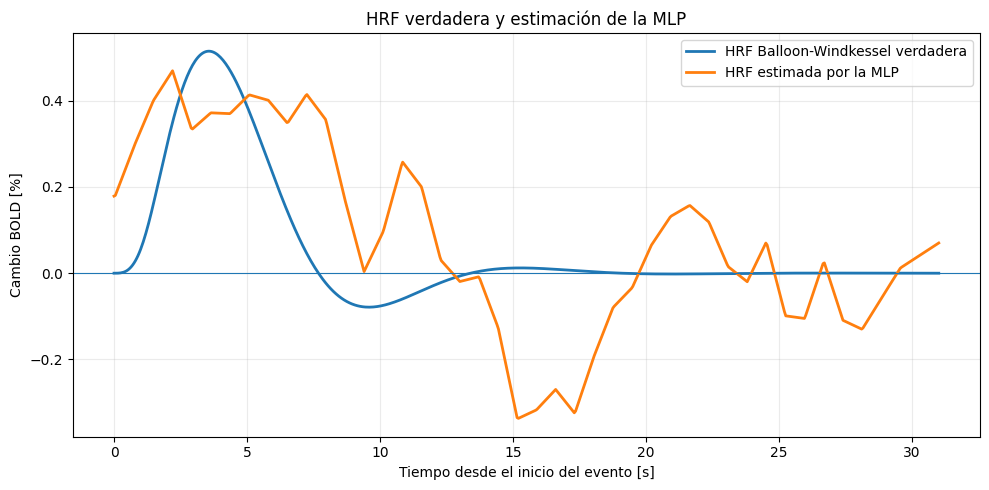

In [22]:
example_hrf = (
    mlp_hrf_estimates.loc[
        (
            mlp_hrf_estimates["scenario"]
            == "motor_lr_m1_left"
        )
        & (
            mlp_hrf_estimates["snr_name"]
            == "snr_2"
        )
        & (
            mlp_hrf_estimates["replicate"]
            == 1
        )
    ]
    .copy()
)

plt.figure(figsize=(10, 5))

plt.plot(
    example_hrf["time_from_onset_s"],
    100.0
    * example_hrf["true_hrf_fraction"],
    linewidth=2.0,
    label="HRF Balloon-Windkessel verdadera",
)

plt.plot(
    example_hrf["time_from_onset_s"],
    100.0
    * example_hrf["estimated_hrf_fraction"],
    linewidth=2.0,
    label="HRF estimada por la MLP",
)

plt.axhline(0.0, linewidth=0.8)
plt.xlabel("Tiempo desde el inicio del evento [s]")
plt.ylabel("Cambio BOLD [%]")
plt.title("HRF verdadera y estimación de la MLP")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

figure_path = (
    FIGURES_DIR
    / "mlp_synthetic_hrf_comparison_snr2.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [23]:
GLM_SUMMARY_PATH = (
    PROJECT_ROOT
    / "results"
    / "synthetic"
    / "glm"
    / "glm_synthetic_grouped_summary.csv"
)

glm_summary = pd.read_csv(
    GLM_SUMMARY_PATH
)

comparison = pd.concat(
    [
        glm_summary.assign(
            model="GLM"
        ),
        mlp_grouped_summary.assign(
            model="MLP"
        ),
    ],
    ignore_index=True,
)

display(
    comparison[
        [
            "model",
            "target_snr",
            "test_rmse_mean",
            "test_r2_mean",
            "hrf_rmse_mean",
            "hrf_r2_mean",
        ]
    ].sort_values(
        [
            "target_snr",
            "model",
        ],
        ascending=[
            False,
            True,
        ],
    )
)

,model,target_snr,test_rmse_mean,test_r2_mean,hrf_rmse_mean,hrf_r2_mean
0,GLM,10.0,0.405537,0.668407,0.122234,0.336438
3,MLP,10.0,0.084914,0.983398,0.241800,-1.622980
1,GLM,5.0,0.409851,0.661308,0.122241,0.336363
4,MLP,5.0,0.108782,0.974516,0.237348,-1.527684
2,GLM,2.0,0.418684,0.645825,0.122222,0.336552
5,MLP,2.0,0.210325,0.906578,0.242118,-1.662893
